# 7.7.稠密连接网络（DenseNet）

ResNet极大地改变了如何参数化深层网络中函数的观点。*稠密连接网络*（DenseNet） [[Huang et al., 2017]](https://zh.d2l.ai/chapter_references/zreferences.html#id73)在某种程度上是ResNet的逻辑扩展。让我们先从数学上了解一下。



---


## 环境准备


In [2]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d, PyPTOAvgPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear
from src.PyPTOBatchNormModule import PyPTOBatchNorm

import pypto
import torch
import torchvision
from torch import nn
from src.D2LFunction import *

# NPU 初始化: 指定设备并初始化 pypto 运行时
import torch_npu
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
pypto.pypto_impl.DeviceInit()

---


## 7.7.1.从ResNet到DenseNet

回想一下任意函数的泰勒展开式（Taylor expansion），它把这个函数分解成越来越高阶的项。在$x$接近0时，

$$f(x) = f(0) + f'(0) x + \frac{f''(0)}{2!}  x^2 + \frac{f'''(0)}{3!}  x^3 + \ldots.\tag{7.7.1}$$

同样，ResNet将函数展开为

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}).\tag{7.7.2}$$

也就是说，ResNet将$f$分解为两部分：一个简单的线性项和一个复杂的非线性项。那么再向前拓展一步，如果我们想将$f$拓展成超过两部分的信息呢？一种方案便是DenseNet。

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="./images/densenet-block.svg">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">图7.7.1 ResNet（左）与 DenseNet（右）在跨层连接上的主要区别：使用相加和使用连结。</p>
</div>
<br />

如 <span style="color: #ffbf00; font-weight: bold;"> 图7.7.1 </span>所示，ResNet和DenseNet的关键区别在于，DenseNet输出是*连接*（用图中的$[,]$表示）而不是如ResNet的简单相加。因此，在应用越来越复杂的函数序列后，我们执行从$\mathbf{x}$到其展开式的映射：

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2([\mathbf{x}, f_1(\mathbf{x})]), f_3([\mathbf{x}, f_1(\mathbf{x}), f_2([\mathbf{x}, f_1(\mathbf{x})])]), \ldots\right].\tag{7.7.3}$$

最后，将这些展开式结合到多层感知机中，再次减少特征的数量。实现起来非常简单：我们不需要添加术语，而是将它们连接起来。DenseNet这个名字由变量之间的“稠密连接”而得来，最后一层与之前的所有层紧密相连。稠密连接如 <span style="color: #ffbf00; font-weight: bold;"> 图7.7.2 </span>所示。

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="./images/densenet.svg">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">图7.7.2 稠密连接。</p>
</div>
<br />

稠密网络主要由2部分构成：*稠密块*（dense block）和*过渡层*（transition layer）。前者定义如何连接输入和输出，而后者则控制通道数量，使其不会太复杂。



---


## 7.7.2.稠密块体

DenseNet使用了ResNet改良版的“批量规范化、激活和卷积”架构（参见 [<span style="color: #ffbf00; font-weight: bold;"> 7.6节 </span>](./07.06_resnet.ipynb)中的练习）。我们首先实现一下这个架构。

本节的批量规范化复用 7.5 节的 PyPTO kernel 版 `PyPTOBatchNorm`（见 `src/PyPTOBatchNormModule.py`，`PyPTOBatchNorm(num_features, 4)` 对应卷积形态），前向/反向及 moving 统计更新均由 kernel 完成。


In [3]:
def conv_block(input_channels, num_channels):
    return nn.Sequential(
        PyPTOBatchNorm(input_channels, 4), nn.ReLU(),
        PyPTOConv2d(input_channels, num_channels, kernel_size=3, padding=1, bias=True))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))</pre>
</div>
</details>

一个*稠密块*由多个卷积块组成，每个卷积块使用相同数量的输出通道。然而，在前向传播中，我们将每个卷积块的输入和输出在通道维上连结。


In [4]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

在下面的例子中，我们定义一个有2个输出通道数为10的`DenseBlock`。使用通道数为3的输入时，我们会得到通道数为$3+2\times 10=23$的输出。卷积块的通道数控制了输出通道数相对于输入通道数的增长，因此也被称为*增长率*（growth rate）。


In [5]:
blk = DenseBlock(2, 3, 10).to('npu:0')
X = torch.randn(4, 3, 8, 8, device='npu:0')
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

---


## 7.7.3.过渡层

由于每个稠密块都会带来通道数的增加，使用过多则会过于复杂化模型。而过渡层可以用来控制模型复杂度。它通过$1\times 1$卷积层来减小通道数，并使用步幅为2的平均汇聚层减半高和宽，从而进一步降低模型复杂度。


In [6]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        PyPTOBatchNorm(input_channels, 4), nn.ReLU(),
        PyPTOConv2d(input_channels, num_channels, kernel_size=1, bias=True),
        PyPTOAvgPool2d(2, 2))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))</pre>
</div>
</details>

对上一个例子中稠密块的输出使用通道数为10的过渡层。此时输出的通道数减为10，高和宽均减半。


In [7]:
blk = transition_block(23, 10).to('npu:0')
blk(Y).shape

torch.Size([4, 10, 4, 4])

---


## 7.7.4.DenseNet模型

我们来构造DenseNet模型。DenseNet首先使用同ResNet一样的单卷积层和最大汇聚层。


In [8]:
b1 = nn.Sequential(
    PyPTOConv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=True),
    PyPTOBatchNorm(64, 4), nn.ReLU(),
    PyPTOMaxPool2d(3, 2, 1))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))</pre>
</div>
</details>

接下来，类似于ResNet使用的4个残差块，DenseNet使用的是4个稠密块。与ResNet类似，我们可以设置每个稠密块使用多少个卷积层。这里我们设成4，从而与 [<span style="color: #ffbf00; font-weight: bold;"> 7.6节 </span>](./07.06_resnet.ipynb)的ResNet-18保持一致。稠密块里的卷积层通道数（即增长率）设为32，所以每个稠密块将增加128个通道。

在每个模块之间，ResNet通过步幅为2的残差块减小高和宽，DenseNet则使用过渡层来减半高和宽，并减半通道数。


In [9]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

与ResNet类似，最后接上全局汇聚层和全连接层来输出结果。


In [10]:
net = nn.Sequential(
    b1, *blks,
    PyPTOBatchNorm(num_channels, 4), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    PyPTOLinear(num_channels, 10)).to('npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))</pre>
</div>
</details>

---


## 7.7.5.训练模型

由于这里使用了比较深的网络，本节里我们将输入高和宽从224降到96来简化计算。


loss 0.121, train acc 0.955, test acc 0.930
67.4 examples/sec on npu:0


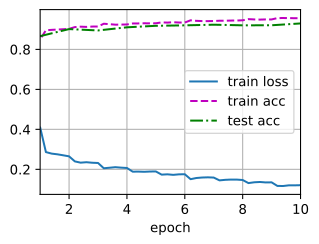

In [11]:
lr, num_epochs, batch_size = 0.001, 10, 64
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=96)
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

---


## 7.7.6.小结

* 在跨层连接上，不同于ResNet中将输入与输出相加，稠密连接网络（DenseNet）在通道维上连结输入与输出。
* DenseNet的主要构建模块是稠密块和过渡层。
* 在构建DenseNet时，我们需要通过添加过渡层来控制网络的维数，从而再次减少通道的数量。



---


## 7.7.7.练习

1. 为什么我们在过渡层使用平均汇聚层而不是最大汇聚层？
2. DenseNet的优点之一是其模型参数比ResNet小。为什么呢？
3. DenseNet一个诟病的问题是内存或显存消耗过多。
    1. 真的是这样吗？可以把输入形状换成$224 \times 224$，来看看实际的显存消耗。
    2. 有另一种方法来减少显存消耗吗？需要改变框架么？
4. 实现DenseNet论文 [[Huang et al., 2017]](https://zh.d2l.ai/chapter_references/zreferences.html#id73)表1所示的不同DenseNet版本。
5. 应用DenseNet的思想设计一个基于多层感知机的模型。将其应用于 [<span style="color: #ffbf00; font-weight: bold;"> 12.14节 </span>](../12_pypto_computer_vision/12.14_kaggle_dog.ipynb)中的房价预测任务。


参考答案详见 [answers/07.07_reference_answer](./answers/07.07_reference_answer.ipynb)。

### 7.7.7.1.参考答案（PyPTO）


In [ ]:
!cat answers/txt/07.07_reference_answer_pypto.txt

### 7.7.7.2.参考答案（PyTorch）


In [ ]:
!cat answers/txt/07.07_reference_answer_pytorch.txt